In [2]:
print("시계열 데이터 분석")

시계열 데이터 분석


In [3]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [6]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line  in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

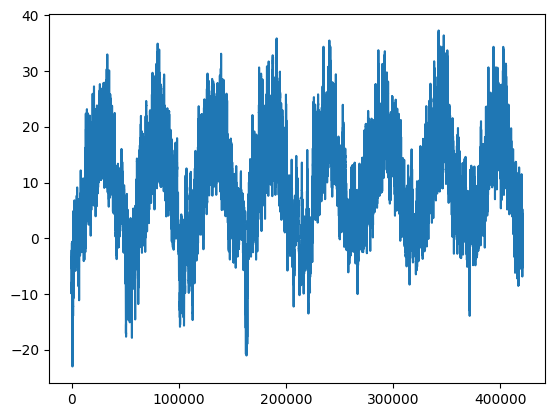

In [7]:
from matplotlib import pyplot as plt
plt.plot(range(len(temperature)), temperature)
plt.show()

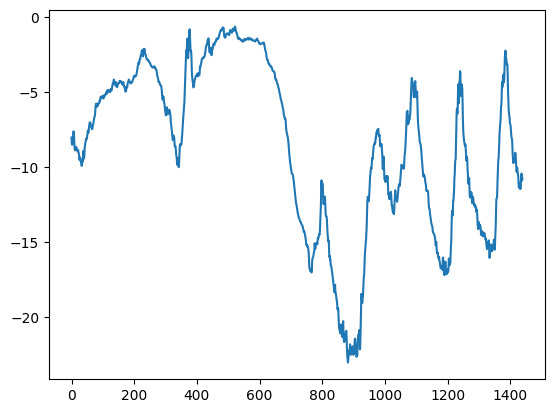

In [8]:
plt.plot(range(1440), temperature[:1440])
plt.show()

In [10]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std
# 데이터 누수 방지를 위해 훈련 데이터의 평균과 표준편차로 전체 데이터를 정규화한다.
# 훈련 데이터의 평균과 표준편차로 전체 데이터를 정규화하는 이유는, 모델이 훈련 데이터에서 학습한 통계적 특성을 기반으로 일반화할 수 있도록 하기 위함

In [14]:
import numpy as np
import tensorflow
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)
for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

2026-05-20 06:31:46.984661: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 06:31:47.341288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-20 06:31:47.541174: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-20 06:31:47.542650: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-20 06:31:47.883184: I tensorflow/core/platform/cpu_feature_gua

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


2026-05-20 06:31:53.228240: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)  # 24시간 이후의 온도를 예측하기 위해 지연을 설정한다.
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

for samples, targets in train_dataset:
    print("샘플의 크기:", samples.shape)
    print("타깃의 크기:", targets.shape)
    break

샘플의 크기: (256, 120, 14)
타깃의 크기: (256,)


In [19]:
def evaluate_naive_method(dataset):
    total_abs_error = 0.
    samplese_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_error += np.sum(np.abs(preds - targets))
        samplese_seen += samples.shape[0]
    return total_abs_error / samplese_seen

print(f"검증 MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"테스트 MAE: {evaluate_naive_method(test_dataset):.2f}")


2026-05-20 07:09:12.579033: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


검증 MAE: 2.44
테스트 MAE: 2.62


2026-05-20 07:09:18.231702: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [29]:

# inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# x = layers.Flatten()(inputs)
# x = layers.Dense(16, activation="relu")(x)
# x = layers.Dense(16, activation="relu")(x)
# outputs = layers.Dense(1)(x)
# model = keras.Model(inputs, outputs)
# callbacks = [
#     keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
# ]
# model.compile(optimizer="rmsprop", loss="mae", metrics=["mae"])
# history = model.fit(train_dataset,
#                     epochs=10,
#                     validation_data=val_dataset,
#                     callbacks=callbacks)
# model = keras.models.load_model("jena_dense.keras")
# print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")





from tensorflow import keras
from tensorflow.keras import layers

num_features = raw_data.shape[-1]

inputs = keras.Input(shape=(sequence_length, num_features))
x = layers.Reshape((sequence_length * num_features,))(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]

model.compile(
    optimizer="rmsprop",
    loss="mae",
    metrics=["mae"],
    jit_compile=False
)

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

model = keras.models.load_model("jena_dense.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 3.1715 - mae: 3.1715 - val_loss: 2.5525 - val_mae: 2.5525
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 2.3833 - mae: 2.3833 - val_loss: 2.5212 - val_mae: 2.5212
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 2.2604 - mae: 2.2604 - val_loss: 2.5488 - val_mae: 2.5488
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 2.1833 - mae: 2.1833 - val_loss: 2.5507 - val_mae: 2.5507
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 2.1362 - mae: 2.1362 - val_loss: 2.5442 - val_mae: 2.5442
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 2.0950 - mae: 2.0950 - val_loss: 2.6587 - val_mae: 2.6587
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 2.0686 - mae: 2.0686 - val_loss: 2.5890 - val_mae: 2.5890
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 2.0427 - mae: 2.0427 - val_loss: 2.5677 - val_mae: 2.5677
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 

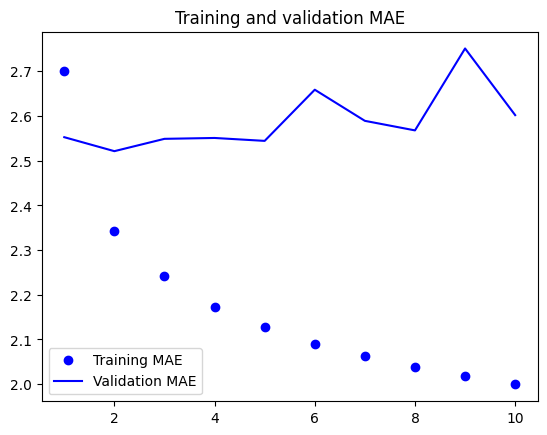

In [30]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [31]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 24, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model("jena_conv.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - loss: 24.6339 - mae: 3.8354 - val_loss: 14.7916 - val_mae: 3.0327
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 14.0312 - mae: 2.9797 - val_loss: 14.5856 - val_mae: 3.0166
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 12.6631 - mae: 2.8264 - val_loss: 14.6672 - val_mae: 3.0203
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 11.8549 - mae: 2.7305 - val_loss: 14.1147 - val_mae: 2.9666
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 11.1692 - mae: 2.6530 - val_loss: 13.4174 - val_mae: 2.8871
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 10.6171 - mae: 2.5830 - val_loss: 12.9778 - val_mae: 2.8426
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 10.2307 - mae: 2.5322 - val_loss: 13.6642 - val_mae: 2.8991
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 9.8759 - mae: 2.4865 - val_loss: 12.8833 - val_mae: 2.8383
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━

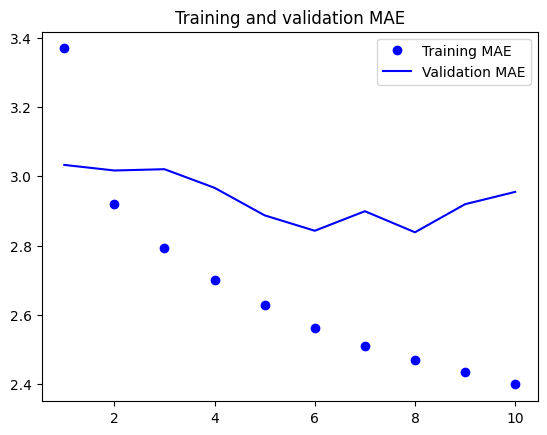

In [33]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [34]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model("jena_conv.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 69.8087 - mae: 6.3956 - val_loss: 12.6703 - val_mae: 2.7130
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 12.3039 - mae: 2.7026 - val_loss: 10.2600 - val_mae: 2.4746
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 9.9883 - mae: 2.4564 - val_loss: 10.2994 - val_mae: 2.4647
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - loss: 9.3784 - mae: 2.3828 - val_loss: 9.6349 - val_mae: 2.4061
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - loss: 9.0143 - mae: 2.3396 - val_loss: 9.5896 - val_mae: 2.3961
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 8.6530 - mae: 2.2935 - val_loss: 9.6305 - val_mae: 2.4198
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 8.3964 - mae: 2.2589 - val_loss: 9.6685 - val_mae: 2.4257
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - loss: 8.1332 - mae: 2.2235 - val_loss: 10.0227 - val_mae: 2.4710
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

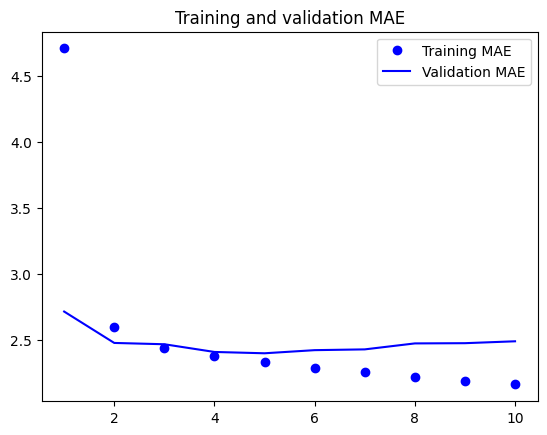

In [35]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model("jena_conv.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
172/819 ━━━━━━━━━━━━━━━━━━━━ 4:37 429ms/step - loss: 87.7875 - mae: 7.3987

In [ ]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()